In [10]:
# Setup paths and imports
import sys
import json
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import librosa

# Add project root to path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from src.config import config
from src.data_loader import DataLoader
from src.detectors import Pipeline, TempoEstimator, BeatTracker
from src.evaluation import Evaluator
from src.utils import extract_if_needed

# Configure paths
config.paths.base_dir = project_root
config.paths.data_raw_dir = project_root / "data" / "raw"
config.paths.data_processed_dir = project_root / "data" / "processed"
config.paths.submissions_dir = project_root / "submissions"

# Create directories
config.paths.data_raw_dir.mkdir(parents=True, exist_ok=True)
config.paths.data_processed_dir.mkdir(parents=True, exist_ok=True)
config.paths.submissions_dir.mkdir(parents=True, exist_ok=True)

print(f"Project root: {project_root}")
print(f"Setup complete: sr={config.audio.sample_rate}, method={config.onset.method}")

Project root: c:\Users\jeron\Documents\JKU\Audio & Music Processing\amp-challenge
Setup complete: sr=22050, method=superflux


In [11]:
# Extract datasets
datasets = [
    ("train", config.paths.data_raw_dir / "train.zip", config.paths.data_processed_dir / "train"),
    ("test", config.paths.data_raw_dir / "test.zip", config.paths.data_processed_dir / "test"),
    ("extra_onsets", config.paths.data_raw_dir / "train_extra_onsets.zip", config.paths.data_processed_dir / "train_extra_onsets"),
    ("extra_tempobeats", config.paths.data_raw_dir / "train_extra_tempobeats.zip", config.paths.data_processed_dir / "train_extra_tempobeats"),
]

for name, zip_path, dest in datasets:
    if zip_path.exists():
        extracted = extract_if_needed(zip_path, dest)
        print(f"{name}: {'extracted' if extracted else 'already exists'}")
    else:
        print(f"{name}: ZIP not found")

train: already exists
test: already exists
extra_onsets: already exists
extra_tempobeats: already exists


In [12]:
# Load all data
loader = DataLoader()

train_dir = config.paths.data_processed_dir / "train"
train_data = loader.load_train(train_dir)
print(f"Training: {len(train_data)} files")

extra_onsets_dir = config.paths.data_processed_dir / "train_extra_onsets"
extra_onsets = loader.load_extra_onsets(extra_onsets_dir) if extra_onsets_dir.exists() else {}
print(f"Extra onsets: {len(extra_onsets)} files")

extra_tempobeats_dir = config.paths.data_processed_dir / "train_extra_tempobeats"
extra_tempobeats = loader.load_extra_tempobeats(extra_tempobeats_dir) if extra_tempobeats_dir.exists() else {}
print(f"Extra tempo/beats: {len(extra_tempobeats)} files")

all_train = {**train_data, **extra_onsets, **extra_tempobeats}
print(f"Total training: {len(all_train)} files")

test_dir = config.paths.data_processed_dir / "test"
test_data = loader.load_test(test_dir)
print(f"Test: {len(test_data)} files")

Loading training data: 100%|██████████| 127/127 [00:00<00:00, 2877.28it/s]


Training: 127 files


Loading extra onsets: 100%|██████████| 150/150 [00:00<00:00, 1573.41it/s]


Extra onsets: 150 files


Loading extra tempo/beats: 100%|██████████| 696/696 [00:00<00:00, 5431.96it/s]


Extra tempo/beats: 696 files
Total training: 973 files


Loading test data: 100%|██████████| 50/50 [00:00<00:00, 82305.81it/s]

Test: 50 files


In [13]:
# Librosa compatibility fix
def fix_librosa_compatibility():
    """Patch detectors to work with different librosa versions."""
    
    def fixed_estimate(self, y, sr):
        onset_env = librosa.onset.onset_strength(y=y, sr=sr, hop_length=self.cfg.audio.tempo_hop_length)
        try:
            tempo = librosa.beat.tempo(onset_envelope=onset_env, sr=sr, 
                                       hop_length=self.cfg.audio.tempo_hop_length,
                                       start_bpm=self.cfg.beat.tempo_min)[0]
        except:
            tempo = librosa.beat.tempo(y=y, sr=sr)[0]
        
        tempos = [float(tempo)]
        if tempo * 2 <= self.cfg.beat.tempo_max:
            tempos.append(float(tempo * 2))
        elif tempo / 2 >= self.cfg.beat.tempo_min:
            tempos.append(float(tempo / 2))
        return tempos
    
    def fixed_track(self, y, sr, tempo=None):
        onset_env = librosa.onset.onset_strength(y=y, sr=sr, hop_length=self.cfg.audio.beat_hop_length)
        if tempo is None:
            try:
                tempo = librosa.beat.tempo(onset_envelope=onset_env, sr=sr,
                                           hop_length=self.cfg.audio.beat_hop_length,
                                           start_bpm=self.cfg.beat.tempo_min)[0]
            except:
                tempo = librosa.beat.tempo(y=y, sr=sr)[0]
            tempo = float(tempo[0]) if isinstance(tempo, np.ndarray) else float(tempo)
        
        try:
            beat_frames = librosa.beat.beat_track(onset_envelope=onset_env, sr=sr,
                                                  hop_length=self.cfg.audio.beat_hop_length,
                                                  start_bpm=tempo, tightness=self.cfg.beat.tightness,
                                                  trim=False)[1]
        except:
            beat_frames = librosa.beat.beat_track(onset_envelope=onset_env, sr=sr,
                                                  hop_length=self.cfg.audio.beat_hop_length,
                                                  start_bpm=tempo, tightness=self.cfg.beat.tightness)[1]
        
        beat_times = librosa.frames_to_time(beat_frames, sr=sr, hop_length=self.cfg.audio.beat_hop_length)
        return beat_times, float(tempo)
    
    TempoEstimator.estimate = fixed_estimate
    BeatTracker.track = fixed_track

fix_librosa_compatibility()
print("Librosa compatibility fix applied")

Librosa compatibility fix applied


In [14]:
# Generate submission for test set
pipeline = Pipeline()
submission = {}

for stem, info in test_data.items():
    y, sr = loader.load_audio(info['wav'])
    if y is None:
        submission[stem] = {'onsets': [], 'beats': [], 'tempo': []}
        continue
    
    onsets, beats, tempos = pipeline.process_file(y, sr)
    submission[stem] = {
        'onsets': onsets.tolist(),
        'beats': beats.tolist(),
        'tempo': tempos
    }

submission_path = config.paths.submissions_dir / "predictions.json"
with open(submission_path, 'w') as f:
    json.dump(submission, f, indent=2)

print(f"Submission saved: {submission_path}")
print(f"Processed {len(submission)} test files")

C:\Users\jeron\AppData\Local\Temp\ipykernel_33892\2931402351.py:8: FutureWarning: librosa.beat.tempo
	This function was moved to 'librosa.feature.rhythm.tempo' in librosa version 0.10.0.
	This alias will be removed in librosa version 1.0.
  tempo = librosa.beat.tempo(onset_envelope=onset_env, sr=sr,


Submission saved: c:\Users\jeron\Documents\JKU\Audio & Music Processing\amp-challenge\submissions\predictions.json
Processed 50 test files


In [22]:
# Fixed evaluation with proper tempo handling
import mir_eval

# Create validation split
items = list(train_data.items())
random.seed(42)
random.shuffle(items)

val_size = min(20, len(items) // 5)
val_items = dict(items[:val_size])

print(f"Validation set: {len(val_items)} files")

# Process validation set
val_predictions = {}
for stem, info in val_items.items():
    y, sr = loader.load_audio(info['wav'])
    if y is None:
        continue
    onsets, beats, tempos = pipeline.process_file(y, sr)
    val_predictions[stem] = {
        'onsets': onsets.tolist(),
        'beats': beats.tolist(),
        'tempo': tempos
    }

# Calculate scores
onset_scores = []
beat_scores = []
tempo_scores = []

for stem, gt in val_items.items():
    if stem not in val_predictions:
        continue
    
    pred = val_predictions[stem]
    
    # Onset score
    if gt.get('onsets') and pred.get('onsets'):
        f, _, _ = mir_eval.onset.f_measure(
            np.array(gt['onsets']),
            np.array(pred['onsets']),
            window=0.05
        )
        onset_scores.append(f)
    
    # Beat score
    if gt.get('beats') and pred.get('beats'):
        f = mir_eval.beat.f_measure(
            np.array(gt['beats']),
            np.array(pred['beats'])
        )
        beat_scores.append(f)
    
    # Tempo score - check if tempo data exists
    if gt.get('tempo') and len(gt['tempo']) > 0 and pred.get('tempo') and len(pred['tempo']) > 0:
        # Handle different tempo formats
        if len(gt['tempo']) == 1:
            # Single tempo: split into half/double
            ref_tempi = np.array([gt['tempo'][0] / 2, gt['tempo'][0]])
            ref_weight = 0.5
        elif len(gt['tempo']) == 2:
            # Two tempos without weight (from our loader)
            ref_tempi = np.array(gt['tempo'])
            ref_weight = 0.5
        elif len(gt['tempo']) == 3:
            # Two tempos with weight
            ref_tempi = np.array(gt['tempo'][:2])
            ref_weight = gt['tempo'][2]
        else:
            print(f"  Skipping {stem}: unexpected tempo format {gt['tempo']}")
            continue
        
        # Format predictions
        est_tempi = np.array(pred['tempo'][:2])
        if len(est_tempi) == 1:
            est_tempi = np.array([est_tempi[0] / 2, est_tempi[0]])
        
        try:
            p_score = mir_eval.tempo.detection(ref_tempi, ref_weight, est_tempi, tol=0.08)
            tempo_scores.append(p_score)
        except Exception as e:
            print(f"  Tempo error for {stem}: {e}")

# Print results
print("\nCHALLENGE EVALUATION RESULTS")
print(f"  Onset F1:  {np.mean(onset_scores):.4f}  ({len(onset_scores)} files)")
print(f"  Beat F1:   {np.mean(beat_scores):.4f}  ({len(beat_scores)} files)")
if tempo_scores:
    print(f"  Tempo:     {np.mean(tempo_scores):.4f}  ({len(tempo_scores)} files)")
    overall = (np.mean(onset_scores) + np.mean(beat_scores) + np.mean(tempo_scores)) / 3
else:
    print(f"  Tempo:     No valid tempo annotations in validation set")
    overall = (np.mean(onset_scores) + np.mean(beat_scores)) / 2
print(f"  MEAN:      {overall:.4f}")

Validation set: 20 files


C:\Users\jeron\AppData\Local\Temp\ipykernel_33892\2931402351.py:8: FutureWarning: librosa.beat.tempo
	This function was moved to 'librosa.feature.rhythm.tempo' in librosa version 0.10.0.
	This alias will be removed in librosa version 1.0.
  tempo = librosa.beat.tempo(onset_envelope=onset_env, sr=sr,



CHALLENGE EVALUATION RESULTS
  Onset F1:  0.4318  (20 files)
  Beat F1:   0.3855  (20 files)
  Tempo:     0.3250  (20 files)
  MEAN:      0.3808


File: ff123_charlies
GT onsets: 74 | Pred: 14
GT beats: 18 | Pred: 13
GT tempo: [41.4022001651, 82.8044003302] | Pred: [41.67716733870968, 83.35433467741936]


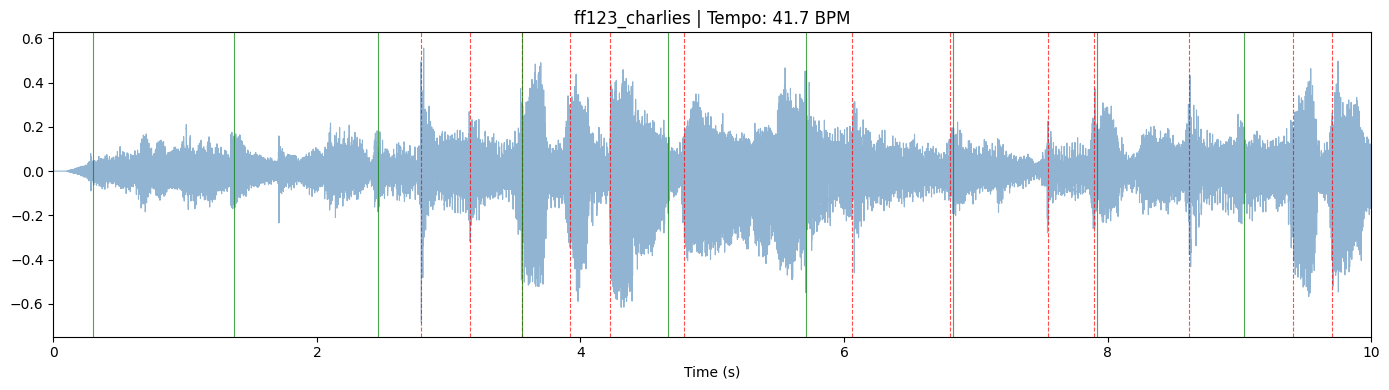

In [16]:
# Visualize results
def visualize(wav_path, onsets, beats, tempos, title=""):
    y, sr = librosa.load(wav_path, sr=config.audio.sample_rate)
    time = np.arange(len(y)) / sr
    
    plt.figure(figsize=(14, 4))
    plt.plot(time, y, alpha=0.6, color='steelblue', linewidth=0.8)
    for o in onsets:
        plt.axvline(x=o, color='red', alpha=0.7, linewidth=0.8, linestyle='--')
    for b in beats:
        plt.axvline(x=b, color='green', alpha=0.7, linewidth=0.8)
    plt.xlabel('Time (s)')
    plt.title(f'{title} | Tempo: {tempos[0]:.1f} BPM')
    plt.xlim(0, min(10, time[-1]))
    plt.tight_layout()
    plt.show()

if val_items:
    stem = list(val_items.keys())[0]
    gt = val_items[stem]
    pred = val_predictions[stem]
    print(f"File: {stem}")
    print(f"GT onsets: {len(gt['onsets'])} | Pred: {len(pred['onsets'])}")
    print(f"GT beats: {len(gt['beats'])} | Pred: {len(pred['beats'])}")
    print(f"GT tempo: {gt['tempo']} | Pred: {pred['tempo']}")
    visualize(gt['wav'], pred['onsets'], pred['beats'], pred['tempo'], stem)

In [17]:
# Fixed parameter sweep
def run_sweep(thresholds, peak_distances):
    results = []
    for thresh in thresholds:
        for dist in peak_distances:
            config.onset.threshold = thresh
            config.onset.peak_distance = dist
            pipeline = Pipeline()
            
            # Process validation set
            preds = {}
            for stem, info in val_items.items():
                y, sr = loader.load_audio(info['wav'])
                if y is None:
                    continue
                o, b, t = pipeline.process_file(y, sr)
                preds[stem] = {'onsets': o.tolist(), 'beats': b.tolist(), 'tempo': t}
            
            # Evaluate all metrics
            onset_f1s = []
            beat_f1s = []
            tempo_scores = []
            
            for stem, gt in val_items.items():
                if stem not in preds:
                    continue
                pred = preds[stem]
                
                # Onsets
                if gt.get('onsets') and pred.get('onsets'):
                    f, _, _ = mir_eval.onset.f_measure(
                        np.array(gt['onsets']), 
                        np.array(pred['onsets']), 
                        window=0.05
                    )
                    onset_f1s.append(f)
                
                # Beats
                if gt.get('beats') and pred.get('beats'):
                    f = mir_eval.beat.f_measure(
                        np.array(gt['beats']), 
                        np.array(pred['beats'])
                    )
                    beat_f1s.append(f)
                
                # Tempo - check actual format
                if gt.get('tempo') and len(gt['tempo']) > 0:
                    # Debug first file
                    if stem == list(val_items.keys())[0]:
                        print(f"  Debug {stem}: GT tempo={gt['tempo']}, Pred tempo={pred['tempo']}")
                    
                    # Format ground truth
                    if len(gt['tempo']) == 1:
                        ref_tempi = np.array([gt['tempo'][0] / 2, gt['tempo'][0]])
                        ref_weight = 0.5
                    elif len(gt['tempo']) == 2:
                        ref_tempi = np.array(gt['tempo'])
                        ref_weight = 0.5
                    elif len(gt['tempo']) == 3:
                        ref_tempi = np.array(gt['tempo'][:2])
                        ref_weight = gt['tempo'][2]
                    else:
                        continue
                    
                    # Format predictions
                    if pred.get('tempo') and len(pred['tempo']) > 0:
                        est_tempi = np.array(pred['tempo'][:2])
                        if len(est_tempi) == 1:
                            est_tempi = np.array([est_tempi[0] / 2, est_tempi[0]])
                        
                        try:
                            p_score = mir_eval.tempo.detection(ref_tempi, ref_weight, est_tempi, tol=0.08)
                            tempo_scores.append(p_score)
                        except Exception as e:
                            print(f"    Tempo error: {e}")
            
            mean_onset = np.mean(onset_f1s) if onset_f1s else 0
            mean_beat = np.mean(beat_f1s) if beat_f1s else 0
            mean_tempo = np.mean(tempo_scores) if tempo_scores else 0
            overall = (mean_onset + mean_beat + mean_tempo) / 3
            
            results.append({
                'threshold': thresh,
                'peak_distance': dist,
                'onset_f1': mean_onset,
                'beat_f1': mean_beat,
                'tempo': mean_tempo,
                'overall': overall
            })
            print(f"thresh={thresh}, dist={dist}: Onset={mean_onset:.4f}, Beat={mean_beat:.4f}, Tempo={mean_tempo:.4f}, Overall={overall:.4f}")
    
    if results:
        best = max(results, key=lambda x: x['overall'])
        print(f"\nBEST: threshold={best['threshold']}, peak_distance={best['peak_distance']}")
        print(f"  Onset F1: {best['onset_f1']:.4f}")
        print(f"  Beat F1:  {best['beat_f1']:.4f}")
        print(f"  Tempo:    {best['tempo']:.4f}")
        print(f"  Overall:  {best['overall']:.4f}")
    return results

# Run sweep
thresholds = [0.08, 0.10, 0.12, 0.14, 0.16]
peak_distances = [2, 3]

results = run_sweep(thresholds, peak_distances)

C:\Users\jeron\AppData\Local\Temp\ipykernel_33892\2931402351.py:8: FutureWarning: librosa.beat.tempo
	This function was moved to 'librosa.feature.rhythm.tempo' in librosa version 0.10.0.
	This alias will be removed in librosa version 1.0.
  tempo = librosa.beat.tempo(onset_envelope=onset_env, sr=sr,


  Debug ff123_charlies: GT tempo=[41.4022001651, 82.8044003302], Pred tempo=[41.67716733870968, 83.35433467741936]
thresh=0.08, dist=2: Onset=0.6153, Beat=0.3855, Tempo=0.3250, Overall=0.4419
  Debug ff123_charlies: GT tempo=[41.4022001651, 82.8044003302], Pred tempo=[41.67716733870968, 83.35433467741936]
thresh=0.08, dist=3: Onset=0.6141, Beat=0.3855, Tempo=0.3250, Overall=0.4415
  Debug ff123_charlies: GT tempo=[41.4022001651, 82.8044003302], Pred tempo=[41.67716733870968, 83.35433467741936]
thresh=0.1, dist=2: Onset=0.5720, Beat=0.3855, Tempo=0.3250, Overall=0.4275
  Debug ff123_charlies: GT tempo=[41.4022001651, 82.8044003302], Pred tempo=[41.67716733870968, 83.35433467741936]
thresh=0.1, dist=3: Onset=0.5711, Beat=0.3855, Tempo=0.3250, Overall=0.4272
  Debug ff123_charlies: GT tempo=[41.4022001651, 82.8044003302], Pred tempo=[41.67716733870968, 83.35433467741936]
thresh=0.12, dist=2: Onset=0.5281, Beat=0.3855, Tempo=0.3250, Overall=0.4129
  Debug ff123_charlies: GT tempo=[41.40220

In [18]:
# Final submission check
with open(submission_path, 'r') as f:
    sub = json.load(f)

print(f"   Submission ready: {submission_path}")
print(f"   Files: {len(sub)}")
print("\n   Sample entries:")
for i, (k, v) in enumerate(list(sub.items())[:3]):
    print(f"   {k}: onsets={len(v['onsets'])}, beats={len(v['beats'])}, tempo={v['tempo']}")
print("\n📤 Upload submissions/predictions.json to https://challenges.cp.jku.at")

   Submission ready: c:\Users\jeron\Documents\JKU\Audio & Music Processing\amp-challenge\submissions\predictions.json
   Files: 50

   Sample entries:
   test01: onsets=42, beats=16, tempo=[34.918707770270274, 69.83741554054055]
   test02: onsets=11, beats=10, tempo=[39.15127840909091, 78.30255681818181]
   test03: onsets=19, beats=7, tempo=[37.99977022058823, 75.99954044117646]

📤 Upload submissions/predictions.json to https://challenges.cp.jku.at
